#Connection to Big Query

In [60]:
from google.cloud import bigquery
from google.colab import auth
from tpot import TPOTClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

#authentification
auth.authenticate_user()

#client for big Query
project_id= 'data-portfolio-gcp-project'
client = bigquery.Client(project=project_id, location='EU')

In [61]:
#get the data and table
dataset_ref= client.dataset('employee_data', project=project_id)
dataset = client.get_dataset(dataset_ref)
table_ref = dataset.table('tbl_hr_data')
table = client.get_table(table_ref)
table.schema

[SchemaField('satisfaction_level', 'FLOAT', 'NULLABLE', None, None, (), None),
 SchemaField('last_evaluation', 'FLOAT', 'NULLABLE', None, None, (), None),
 SchemaField('number_project', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('average_montly_hours', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('time_spend_company', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('Work_accident', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('Quit_the_Company', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('promotion_last_5years', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('Departments', 'STRING', 'NULLABLE', None, None, (), None),
 SchemaField('salary', 'STRING', 'NULLABLE', None, None, (), None),
 SchemaField('employee_id', 'STRING', 'NULLABLE', None, None, (), None)]

In [62]:
new_table_ref=dataset.table('tbl_new_employees')
new_table = client.get_table(new_table_ref)
new_table.schema

[SchemaField('satisfaction_level', 'FLOAT', 'NULLABLE', None, None, (), None),
 SchemaField('last_evaluation', 'FLOAT', 'NULLABLE', None, None, (), None),
 SchemaField('number_project', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('average_montly_hours', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('time_spend_company', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('Work_accident', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('Quit_the_Company', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('promotion_last_5years', 'INTEGER', 'NULLABLE', None, None, (), None),
 SchemaField('Departments', 'STRING', 'NULLABLE', None, None, (), None),
 SchemaField('salary', 'STRING', 'NULLABLE', None, None, (), None),
 SchemaField('employee_id', 'STRING', 'NULLABLE', None, None, (), None)]

In [63]:
#convert to dataframe
df = client.list_rows(table=table).to_dataframe()
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,Quit_the_Company,promotion_last_5years,Departments,salary,employee_id
0,0.38,0.53,2,157,3,0,1,0,sales,low,EMP00001
1,0.80,0.86,5,262,6,0,1,0,sales,medium,EMP00002
2,0.11,0.88,7,272,4,0,1,0,sales,medium,EMP00003
3,0.72,0.87,5,223,5,0,1,0,sales,low,EMP00004
4,0.37,0.52,2,159,3,0,1,0,sales,low,EMP00005


In [64]:
#convert to dataframe
df_new = client.list_rows(table=new_table).to_dataframe()
df_new.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,Quit_the_Company,promotion_last_5years,Departments,salary,employee_id
0,0.537849,0.122914,2,208,2,0,0,0,IT,high,NE15043
1,0.056211,0.322600,2,229,5,1,0,0,IT,low,NE15086
2,0.555186,0.555949,2,187,3,0,0,0,RandD,medium,NE15035
3,0.605273,0.713086,2,218,3,0,0,0,RandD,high,NE15069
4,0.043437,0.162372,2,175,3,0,0,0,RandD,high,NE15082


# Prepare data

In [65]:
X = df.drop(columns=['Quit_the_Company', 'employee_id'])
y = df['Quit_the_Company']

# For new employees data
X_new = df_new.drop(columns=['employee_id', 'Quit_the_Company'])

In [66]:
# Encode categorical variables
X = pd.get_dummies(X, columns=['salary', 'Departments'], drop_first=True)
X_new = pd.get_dummies(X_new, columns=['salary', 'Departments'], drop_first=True)

In [67]:
# Split the 'old employee' dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Create and train AutoML model

Why use an AutoML model?

1-Automates model selection

Instead of manually testing different algorithms (Random Forest, XGBoost, Gradient Boosting, etc.), AutoML automatically tries multiple models and finds the one that performs best for your data.

2- Builds complete pipelines (preprocessing + model + hyperparameters)
It can automatically handle preprocessing steps (encoding categorical variables, scaling, feature selection) and combine them with the model in one pipeline. This ensures reproducibility and reduces human errors.


In [68]:
tpot = TPOTClassifier(
    generations=2,       # number of iterations
    population_size=10,  # number of pipelines per generation
    random_state=123,
    n_jobs=1            # use all CPU cores
)

In [69]:
# Fit TPOT on training data
tpot.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/tpot/tpot_estimator/estimator.py:458: UserWarning: Both generations and max_time_mins are set. TPOT will terminate when the first condition is met.
  warnings.warn("Both generations and max_time_mins are set. TPOT will terminate when the first condition is met.")
/usr/local/lib/python3.12/dist-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 38481 instead
  warnings.warn(
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:34061
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:38481/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:33227'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:42823 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:42823
INFO:dis

,search_space,<tpot.search_...x7e1cdfc17ef0>
,scorers,['roc_auc_ovr']
,scorers_weights,[1]
,cv,10
,other_objective_functions,[]
,other_objective_functions_weights,[]
,objective_function_names,None
,bigger_is_better,True
,categorical_features,None
,memory,None
,preprocessing,False


In [70]:
#Plot the tpot pipeline
tpot.fitted_pipeline_

,steps,"[('standardscaler', ...), ('variancethreshold', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,threshold,0.0409242926362
,transformer_list,"[('skiptransformer', ...), ('passthrough', ...)]"
,n_jobs,None
,transformer_weights,None


In [71]:
# Predict on the test set
y_pred = tpot.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99      2288
         1.0       1.00      0.93      0.96       713

    accuracy                           0.98      3001
   macro avg       0.99      0.96      0.97      3001
weighted avg       0.98      0.98      0.98      3001



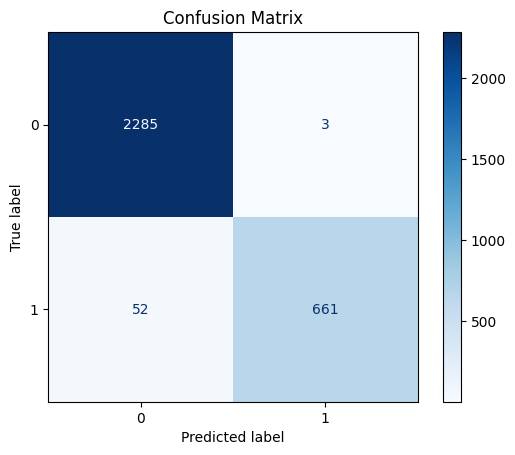

In [72]:
# Plot Confusion matrix on test set
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

The model is slightly more likely to miss some employees who will leave than to falsely flag someone as leaving.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but HistGradientBoostingClassifier was fitted without feature names
  warnings.warn(


              feature  importance
7          salary_low    0.002799
8       salary_medium    0.001566
15  Departments_sales    0.001066
2      number_project    0.000133
9   Departments_RandD    0.000000


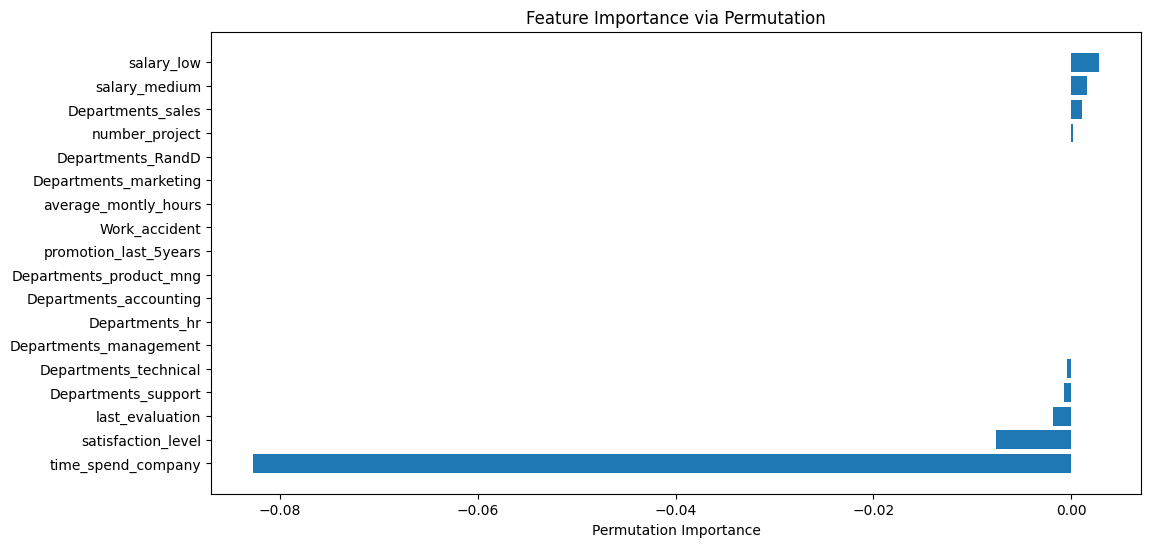

In [76]:
from sklearn.inspection import permutation_importance

final_model = tpot.fitted_pipeline_.steps[-1][1]

# Compute permutation importance
result = permutation_importance(
    final_model, X_test, y_test, n_repeats=10, random_state=123, n_jobs=-1
)

# Create feature table
feature_table = pd.DataFrame({
    'feature': X.columns,
    'importance': result.importances_mean
}).sort_values(by='importance', ascending=False)

print(feature_table.head())

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.barh(feature_table['feature'], feature_table['importance'])
plt.gca().invert_yaxis()
plt.xlabel("Permutation Importance")
plt.title("Feature Importance via Permutation")
plt.show()

Salary matters: Employees with lower salaries are more likely to leave.

Department focus: Sales department shows slightly higher churn risk.

Retention indicators: Longer tenure and higher satisfaction significantly reduce turnover risk.

Other factors: Number of projects, promotions, work accidents, and most departments have very little influence in this dataset.

# Predict churn for new employees

In [73]:
# Predicted class labels
df_new['Predicted_churn'] = tpot.predict(X_new)

# Optional: predicted probabilities for leaving
df_new['Churn_probability'] = tpot.predict_proba(X_new)[:, 1]

In [74]:

df_new

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,Quit_the_Company,promotion_last_5years,Departments,salary,employee_id,Predicted_churn,Churn_probability
0,0.537849,0.122914,2,208,2,0,0,0,IT,high,NE15043,0.0,0.012408
1,0.056211,0.322600,2,229,5,1,0,0,IT,low,NE15086,0.0,0.326789
2,0.555186,0.555949,2,187,3,0,0,0,RandD,medium,NE15035,0.0,0.010639
3,0.605273,0.713086,2,218,3,0,0,0,RandD,high,NE15069,0.0,0.021196
4,0.043437,0.162372,2,175,3,0,0,0,RandD,high,NE15082,0.0,0.233306
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.205280,0.616096,6,153,3,1,0,1,sales,low,NE15059,0.0,0.048836
96,0.976977,0.860386,6,296,3,0,0,0,sales,medium,NE15067,0.0,0.311910
97,0.691851,0.389109,6,207,2,1,0,0,technical,low,NE15007,0.0,0.074795
98,0.827268,0.779616,7,224,2,0,0,0,sales,low,NE15034,0.0,0.239763


# Write back data to bigquery

In [75]:
df_new.to_gbq('employee_data.pilot_predictions',
              project_id,
              chunksize = None,
              if_exists='replace'
              )

/tmp/ipython-input-2495275698.py:1: FutureWarning: Starting with pandas version 3.0 all arguments of to_gbq except for the argument 'destination_table' will be keyword-only.
  df_new.to_gbq('employee_data.pilot_predictions',
/tmp/ipython-input-2495275698.py:1: FutureWarning: to_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.to_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.to_gbq
  df_new.to_gbq('employee_data.pilot_predictions',
100%|██████████| 1/1 [00:00<00:00, 9962.72it/s]


In [77]:
#
feature_table.to_gbq('employee_data.feature_table',
                     project_id,
                     chunksize = None,
                     if_exists='replace'
)

/tmp/ipython-input-1325075480.py:1: FutureWarning: Starting with pandas version 3.0 all arguments of to_gbq except for the argument 'destination_table' will be keyword-only.
  feature_table.to_gbq('employee_data.feature_table',
/tmp/ipython-input-1325075480.py:1: FutureWarning: to_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.to_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.to_gbq
  feature_table.to_gbq('employee_data.feature_table',
100%|██████████| 1/1 [00:00<00:00, 8240.28it/s]
